In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.model_selection import cross_val_predict

In [5]:
df = pd.read_csv('HR_comma_sep.csv')
df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,sales,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   sales                  14999 non-null  str    
 9   salary                 14999 non-null  str    
dtypes: float64(2), int64(6), str(2)
memory usage: 1.1 MB


In [11]:
df.describe()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


In [13]:
df.Work_accident.value_counts(normalize=True)

Work_accident
0    0.85539
1    0.14461
Name: proportion, dtype: float64

In [14]:
df.left.value_counts(normalize=True)

left
0    0.761917
1    0.238083
Name: proportion, dtype: float64

In [15]:
df.promotion_last_5years.value_counts(normalize=True)

promotion_last_5years
0    0.978732
1    0.021268
Name: proportion, dtype: float64

In [17]:
df.rename(columns={'sales': 'department'}, inplace=True)

In [19]:
df.salary.value_counts(normalize=True)

salary
low       0.487766
medium    0.429762
high      0.082472
Name: proportion, dtype: float64

In [20]:
df.isna().sum()

satisfaction_level       0
last_evaluation          0
number_project           0
average_montly_hours     0
time_spend_company       0
Work_accident            0
left                     0
promotion_last_5years    0
department               0
salary                   0
dtype: int64

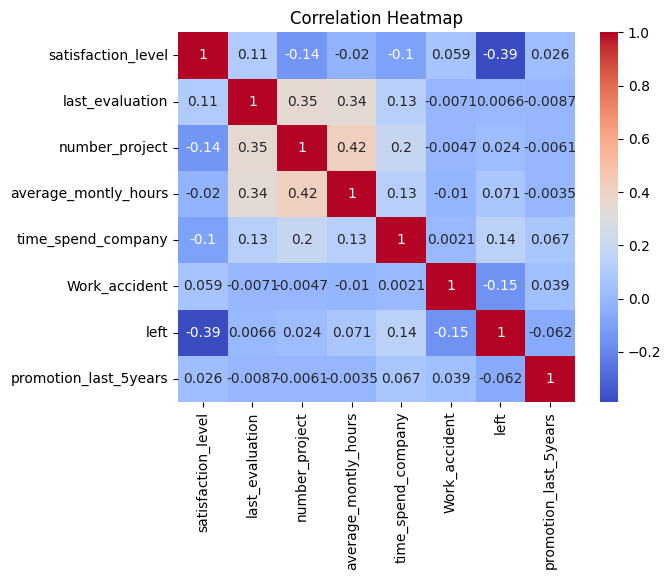

In [24]:
## 2.1 Create a Heatmap
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

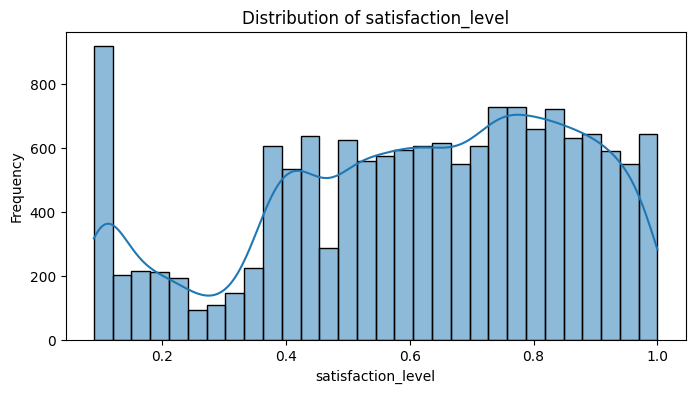

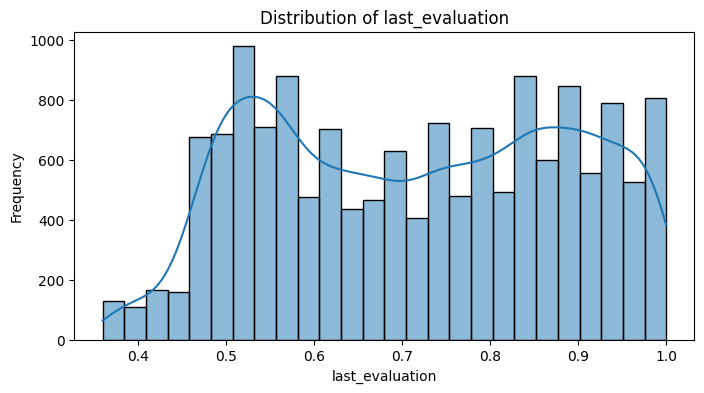

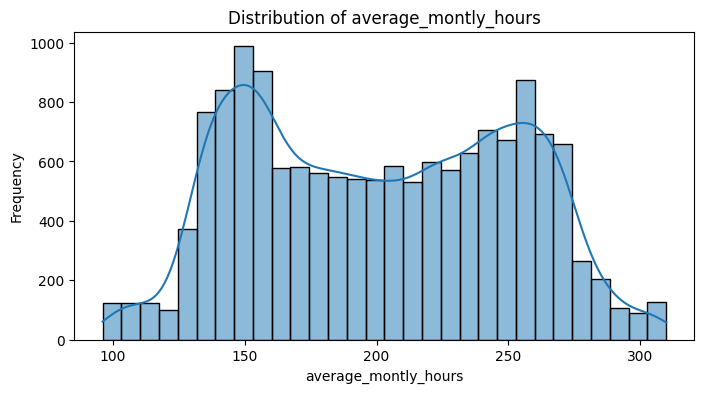

In [25]:
## 2.2 Draw the distribution plot for the 'satisfaction_level', 'last_evaluation', and 'average_montly_hours' columns.
features = ['satisfaction_level', 'last_evaluation', 'average_montly_hours']
for feature in features:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[feature], kde=True)
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')
    plt.show()

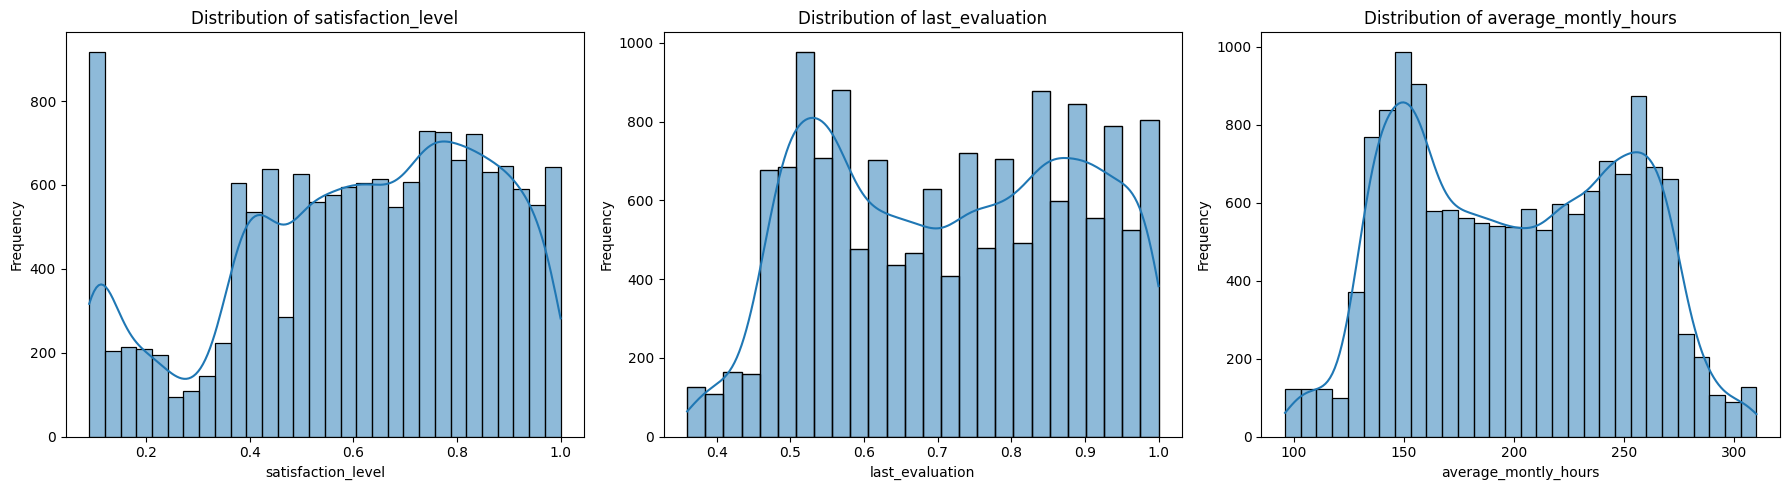

In [26]:
features = ['satisfaction_level', 'last_evaluation', 'average_montly_hours']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, feature in enumerate(features):
    sns.histplot(df[feature], kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {feature}')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Frequency')
plt.tight_layout()
plt.show()

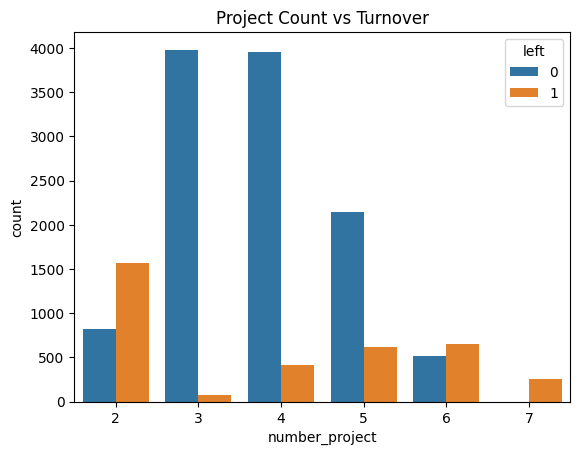

In [29]:
## 2.3 Bar plot
sns.countplot(x='number_project', hue='left', data=df)
plt.title('Project Count vs Turnover')
plt.show()

In [33]:
## 3 Clustering Analysis

left_df = df[df['left'] == 1][['satisfaction_level', 'last_evaluation']]
KMeans = KMeans(n_clusters=3, random_state=42)
left_df['cluster'] = KMeans.fit_predict(left_df)

In [34]:
left_df.head()

,satisfaction_level,last_evaluation,cluster
0,0.38,0.53,0
1,0.80,0.86,1
2,0.11,0.88,2
3,0.72,0.87,1
4,0.37,0.52,0


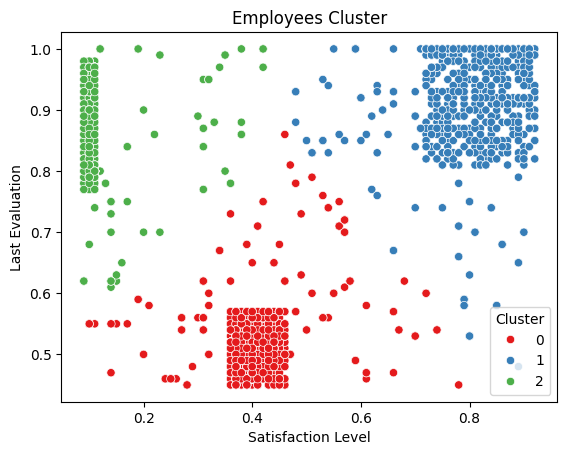

In [35]:
sns.scatterplot(x='satisfaction_level', y='last_evaluation', hue='cluster', data=left_df, palette='Set1')
plt.title('Employees Cluster')
plt.xlabel('Satisfaction Level')
plt.ylabel('Last Evaluation')
plt.legend(title='Cluster')
plt.show()

In [38]:
## 4 Data Preprocessing for Machine Learning

cat_cols = ['department', 'salary']
num_cols = [col for col in df.columns if col not in cat_cols]

cat_df = pd.get_dummies(df[cat_cols], drop_first=True)
num_df = df[num_cols]
final_df = pd.concat([num_df, cat_df], axis=1)
final_df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,department_RandD,department_accounting,department_hr,department_management,department_marketing,department_product_mng,department_sales,department_support,department_technical,salary_low,salary_medium
0,0.38,0.53,2,157,3,0,1,0,False,False,False,False,False,False,True,False,False,True,False
1,0.80,0.86,5,262,6,0,1,0,False,False,False,False,False,False,True,False,False,False,True
2,0.11,0.88,7,272,4,0,1,0,False,False,False,False,False,False,True,False,False,False,True
3,0.72,0.87,5,223,5,0,1,0,False,False,False,False,False,False,True,False,False,True,False
4,0.37,0.52,2,159,3,0,1,0,False,False,False,False,False,False,True,False,False,True,False


In [ ]:
## SMOTE technique for handling class imbalance

X = final_df.drop('left', axis=1)
y = final_df['left']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123,stratify=y)

In [46]:
SMOTE = SMOTE(random_state=123)
X_train_smote, y_train_smote = SMOTE.fit_resample(X_train, y_train)

In [52]:
# Model training and evaluation code would go here, but is not included in the provided snippet.

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=123),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=123)}
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)

results = {}
for model_name, model in models.items():
    y_pred = cross_val_predict(model, X_train_smote, y_train_smote, cv=skf)
    print(f"Model: {model_name} Classification Report:\n{classification_report(y_train_smote, y_pred)}")
    results[model_name] = classification_report(y_train_smote, y_pred, output_dict=True)

Model: Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.77      0.79      9142
           1       0.78      0.82      0.80      9142

    accuracy                           0.80     18284
   macro avg       0.80      0.80      0.79     18284
weighted avg       0.80      0.80      0.79     18284

Model: Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      9142
           1       1.00      0.97      0.98      9142

    accuracy                           0.98     18284
   macro avg       0.99      0.98      0.98     18284
weighted avg       0.99      0.98      0.98     18284

Model: Gradient Boosting Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.98      0.96      9142
           1       0.98      0.95      0.96      9142

    accuracy                           0

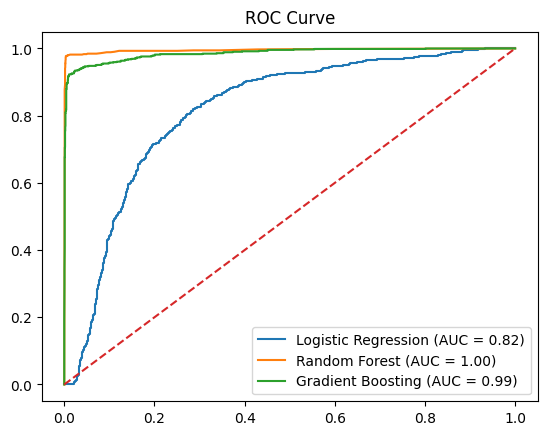

In [54]:
# ROC Curve

plt.Figure()

for model_name, model in models.items():
    model.fit(X_train_smote, y_train_smote)
    probs = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {auc:.2f})')

plt.plot([0, 1], [0, 1], '--')
plt.legend()
plt.title('ROC Curve')
plt.show()

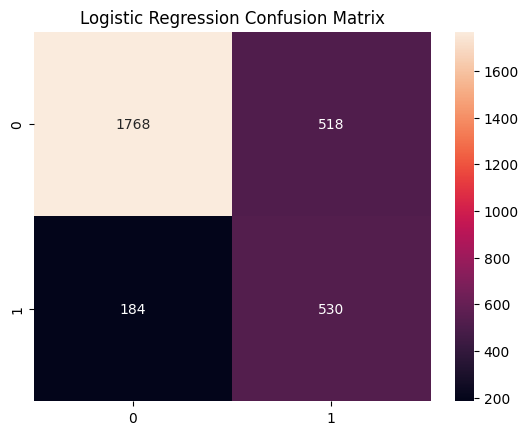

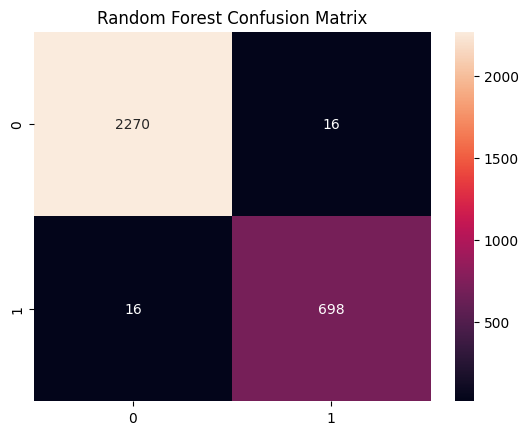

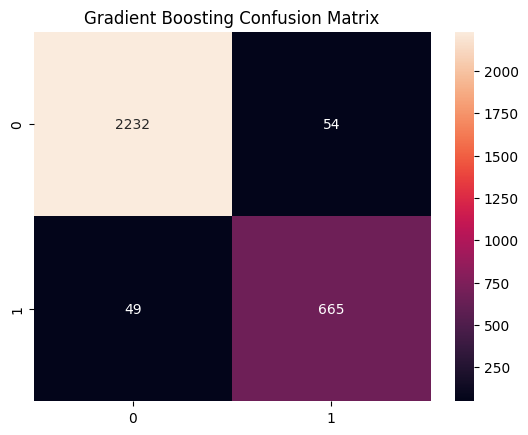

In [55]:
# Confusion Matrix
for model_name, model in models.items():
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title(f'{model_name} Confusion Matrix')
    plt.show()

In [56]:
# Best Model

best_model = GradientBoostingClassifier()
best_model.fit(X_train_smote, y_train_smote)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

In [58]:
probs = best_model.predict_proba(X_test)[:, 1]

zones = []

for p in probs:
    if p < 0.2:
        zones.append('Safe')
    elif p < 0.6:
        zones.append('Low Risk')
    elif p < 0.9:
            zones.append('Medium Risk')
    else:
        zones.append('High Risk')

output = X_test.copy()
output['Actual'] = y_test
output['Predicted_Prob'] = probs
output['Risk_Zone'] = zones

output.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,promotion_last_5years,department_RandD,department_accounting,department_hr,...,department_marketing,department_product_mng,department_sales,department_support,department_technical,salary_low,salary_medium,Actual,Predicted_Prob,Risk_Zone
10627,0.98,0.77,3,191,2,0,0,False,False,False,...,False,False,True,False,False,False,True,0,0.006051,Safe
2703,0.76,0.93,3,271,5,0,0,False,False,True,...,False,False,False,False,False,True,False,0,0.953883,High Risk
6059,0.70,0.93,3,185,4,0,0,False,True,False,...,False,False,False,False,False,False,True,0,0.092444,Safe
3258,0.48,0.61,3,223,3,1,0,False,False,False,...,False,False,False,True,False,False,True,0,0.018464,Safe
4565,0.57,0.90,3,144,2,0,0,False,False,False,...,False,False,False,False,False,False,True,0,0.026333,Safe


In [59]:
print("""
Safe Zone: Maintain engagement
Low Risk: Monitor performance and satisfaction
Medium Risk: Provide incentives and growth opportunities
High Risk: Immediate intervention and retention plans
""")


Safe Zone: Maintain engagement
Low Risk: Monitor performance and satisfaction
Medium Risk: Provide incentives and growth opportunities
High Risk: Immediate intervention and retention plans

